# 期末課題

## 画像の回転処理の実装と数理的考察

### 佐藤奎汰　24B30549

### 概要
本レポートの目的は、画像処理における基本的な操作の一つである「画像の回転処理」を数学的に理解し、実際にnumpyを用いて実装することである。具体的には、以下の項目を達成することを目指す。ただし、回転後の画像は全体を出力する。


**１．回転行列を用いた回転処理**

画像の回転を行う線形代数の理論、回転行列について理解する。出力画像の各ピクセルが入力画像のどのピクセルに由来するかを探す逆マッピングを理解する。

**２．補間処理の実装と比較**

回転処理に不可欠となる補間処理に関して、最近傍補間、バイリニア補間の各手法を実装し、それぞれのアルゴリズムの違いをまとめる。さらに、これらの補完方法が回転後の画質に与える影響について考察する。


**３．性能分析とライブラリとの比較**

numpyで実装した結果を、openCVを用いた場合と比較することでライブラリを用いる場合との違いを考察する。さらに、これらの実装に基づき、異なる補間方法が回転後の画質に与える影響を客観的指標で定量比較するとともに、処理時間を測定し、画質の精度と処理速度の関係について考察する。


### ライブラリのインポートと画像の読み込み

In [16]:
import numpy as np
import cv2 as cv
import math
import matplotlib.pyplot as plt
import timeit

#画像をimgとして読み込む
img = cv.imread('honkan.jpg')

### 回転と回転行列

回転の実装
画像はピクセルから構成されており、各ピクセルは座標成分を持っている。この座標成分に回転行列をかけることでその成分を任意の角度だけ回転させることができる。

$\theta$ 回転させる回転行列は以下のように定義される。

$$
R(\theta) =
\begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix}
$$

任意の点$(x,y)$を原点を中心として$\theta$回転させた点$(x',y')$は以下のように表せる。

$$
\begin{pmatrix} x' \\ y' \end{pmatrix} = \begin{pmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix}
$$

回転の中心を$(a,b)$とすると、回転後の座標$(x',y')$は以下のように表せる。

$$
\begin{pmatrix} x'-a \\ y'-b \end{pmatrix} = \begin{pmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{pmatrix} \begin{pmatrix} x-a \\ y-b \end{pmatrix}
$$

In [17]:
#angleの回転行列を返す関数

# 回転行列
def matrix_R(angle):
    theta = math.radians(angle)

    # 回転行列
    R = np.array([
    [math.cos(theta), -math.sin(theta)],
    [math.sin(theta),  math.cos(theta)]
    ])
    return R

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


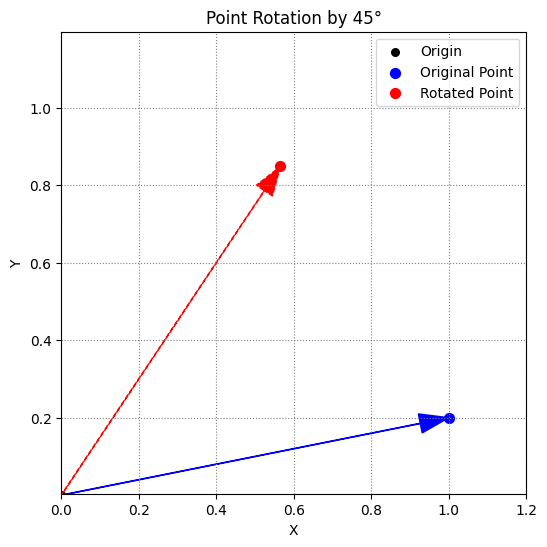

In [18]:
#回転行列をかけることで座標を回転させる例

# 回転行列
R = matrix_R(45)

# 回転前の点 (例として (1, 0) を使用)
point_original = np.array([1.0, 0.2])

# 回転後の点
point_rotated = R @ (point_original)

# --- 描画 ---
plt.figure(figsize=(6, 6))

# 原点
plt.scatter(0, 0, color='black', s=30, label='Origin')

# 元の点
plt.scatter(point_original[0], point_original[1], color='blue', s=50, label='Original Point')
plt.arrow(
    0, 0,
    point_original[0], point_original[1],
    head_width=0.05, length_includes_head=True, 
    color='blue', linestyle='-'
)

# 回転後の点
plt.scatter(point_rotated[0], point_rotated[1], color='red', s=50, label='Rotated Point')
plt.arrow(
    0, 0,
    point_rotated[0], point_rotated[1],
    head_width=0.05, length_includes_head=True,
    color='red', linestyle='--'
)

# 目盛を等しく
plt.axis('equal')
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)

# グリッドとラベル
plt.grid(True, linestyle=':', color='gray')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Point Rotation by {45}°')

# 凡例表示
plt.legend(loc='upper right')

plt.show()


### 逆マッピング

画像の回転では出力画像の各ピクセルが入力画像のどのピクセルに由来するかを探す方法がより一般的である。なぜなら順方向のマッピングでは元画像の二つのピクセルが一つのピクセルに対応する場合があり、このとき出力画像に穴ができてしまうためである。

逆マッピングでは、出力画像のピクセル座標$(x',y')$が与えられたときに、それが入力画像のどの座標から来たのかを計算する。つまり、$(x',y')$を $-\theta$ だけ回転させる。

したがって、使用する回転行列は$R(-\theta)$である。回転行列は直行行列であるため、その逆行列、つまり$R(-\theta)$ は転置行列と等しくなる。

$$ R(-\theta) = R(\theta)^{-1} = R(\theta)^T$$

よって入力画像の座標$(x,y)$は出力画像の座標$(x',y')$を用いて以下のように表せる

$$
\begin{pmatrix} x \\ y \end{pmatrix} =  R(\theta)^T\begin{pmatrix} x' \\ y' \end{pmatrix}
$$

In [19]:
#回転行列の転置

def R_inv(R):
    R_T = R.T
    return R_T

### 入出力画像のサイズ、回転後の最小座標の取得

In [20]:
def size(img, R):
    h_input, w_input, channel = img.shape
    #回転後の四隅の座標を決定
    c_1 = R @ np.array([w_input, 0])
    c_2 = R @ np.array([w_input, h_input])
    c_3 = R @ np.array([0, h_input])
    c_4 = R @ np.array([0, 0])

    #回転後の四隅の最大、最小
    x_min = min(c_1[0], c_2[0], c_3[0], c_4[0])
    x_max = max(c_1[0], c_2[0], c_3[0], c_4[0])
    y_min = min(c_1[1], c_2[1], c_3[1], c_4[1])
    y_max = max(c_1[1], c_2[1], c_3[1], c_4[1])

    #回転後の座標の大きさを決定
    h_output = round(abs(y_max - y_min))
    w_output = round(abs(x_max - x_min))

    return h_input,w_input,x_min, y_min, h_output,w_output

### 補間処理

回転行列をかけることで得られた座標は整数でないことの方が多いが、ピクセルの座標は整数で表される。そのためここで得られた座標を整数に変換する必要がある。ここでは最近傍補間、バイリニア補間を行う。






### 最近傍補間

##### 原理

非整数座標$(x,y)$に最も近い整数座標のピクセルの値を$(x,y)$のピクセル値として採用する。

##### アルゴリズム

$(x,y)$の値を四捨五入して整数値を得る。非整数の$(x,y)$を引数にとり、最近傍補間によって得られた整数の$(x',y')$を戻り値にもつ関数は以下のように表せる。


### バイリニア補間

##### 原理

非整数座標$(x,y)$を囲む4つのピクセルを使用し、$x$方向、$y$方向でそれぞれ線形補間を行う。つまり、$x$方向でその色の平均を算出し、次に$y$方向で色の平均を算出することであるピクセルの色を特定する。カラー画像ではRGBそれぞれについて平均を算出する。

##### アルゴリズム

$(x,y)$を囲む4つのピクセルを以下のように決定する。

$$P_{11} \text{ at } (\lfloor x \rfloor, \lfloor y \rfloor) \\
P_{21} \text{ at } (\lceil x \rceil, \lfloor y \rfloor) \\
P_{12} \text{ at } (\lfloor x \rfloor, \lceil y \rceil) \\
P_{22} \text{ at } (\lceil x \rceil, \lceil y \rceil)$$

まず、$x$方向について、色の平均値を算出する。具体的には、非整数座標 $(x,y)$ に対して、$x$座標の整数部分を $\lfloor x \rfloor$、小数部分を $dx = x - \lfloor x \rfloor$ とする。
この $dx$ を重みとして、$y = \lfloor y \rfloor$ のライン上にあるピクセル $P_{11}$ (座標 $(\lfloor x \rfloor, \lfloor y \rfloor)$) と $P_{21}$ (座標 $(\lceil x \rceil, \lfloor y \rfloor)$) の間で線形補間を行い、中間的なピクセル値 $I_1$ を求める。

$$I_1 = (1-dx) \cdot \text{Value}(P_{11}) + dx \cdot \text{Value}(P_{21})$$

同様に、$y = \lceil y \rceil$ のライン上にあるピクセル $P_{12}$ (座標 $(\lfloor x \rfloor, \lceil y \rceil)$) と $P_{22}$ (座標 $(\lceil x \rceil, \lceil y \rceil)$) の間で線形補間を行い、中間的なピクセル値 $I_2$ を求める。

$$I_2 = (1-dx) \cdot \text{Value}(P_{12}) + dx \cdot \text{Value}(P_{22})$$

ここで、$\text{Value}(P_{ij})$ はピクセル $P_{ij}$ の各色成分の値を指す。

次に、これらの$x$方向の補間結果 $I_1$ と $I_2$ を用いて、$y$方向の線形補間を行う。
$y$座標の整数部分を $\lfloor y \rfloor$、小数部分を $dy = y - \lfloor y \rfloor$ とする。
この $dy$ を重みとして、$I_1$ と $I_2$ の間で線形補間を行い、最終的な非整数座標 $(x,y)$ におけるピクセル値 $I(x,y)$ を算出する。

$$I(x,y) = (1-dy) \cdot I_1 + dy \cdot I_2$$

これらの計算を各色チャンネル（R, G, B）に対して独立に行う。

### numpyを用いた実装
引数を入力画像、回転行列とし、戻り値を出力画像とした関数を作成する。

In [21]:
#順マッピング・最近傍補間
def rotate_forword(img,R):

    #入出力画像のサイズ、最小座標の取得
    h_input,w_input,x_min, y_min, h_output,w_output=size(img,R)

    #出力画像の定義
    rotated = np.zeros((h_output, w_output, 3), dtype=np.uint8)

    #画像のマッピング
    for y in range(h_input):
        for x in range(w_input):
            
            # 原点中心で回転
            vec = np.array([x, y])
            new_vec = R @ vec

            # 画像全体が出力されるように平行移動
            x_new, y_new = new_vec - np.array([x_min, y_min])

            # 順方向で最近傍補間（四捨五入して整数化）
            if 0 <= x < w_input and 0 <= y < h_input:
              x_new = int(round(x_new))
              y_new = int(round(y_new))
              # 回転後のピクセルに元画像のピクセル値を代入
              rotated[y_new, x_new] = img[y, x]

    #BGRからRGBに変換
    rotated = cv.cvtColor(rotated, cv.COLOR_BGR2RGB)
    return rotated

In [22]:
#逆マッピング・最近傍補間
def rotate_inverse(img,R):

  #入出力画像のサイズ、最小座標の取得
  h_input,w_input,x_min, y_min, h_output,w_output=size(img,R)

  #出力画像を定義
  rotated = np.zeros((h_output, w_output, 3), dtype=np.uint8)

  #回転行列の転置
  R_T = R_inv(R)

  #逆マッピング
  for y in range(h_output):
    for x in range(w_output):
        # 画像全体が出力されるように平行移動
        vec = np.array([x, y])+np.array([x_min, y_min])
        new_vec = R_T @ vec
        x_new, y_new = new_vec
        # 最近傍補間（四捨五入して整数化）
        x_new, y_new = int(round(x_new)), int(round(y_new))
        if 0 <= x_new < w_input and 0 <= y_new < h_input:
          rotated[y, x] = img[y_new, x_new]
          
  #BGRからRGBに変換
  rotated = cv.cvtColor(rotated, cv.COLOR_BGR2RGB)
  return rotated

In [23]:
#バイリニア補間（逆マッピング）
def rotate_bilinear(img, R):

    #入出力画像のサイズ、最小座標の取得
    h_input,w_input,x_min, y_min, h_output,w_output=size(img,R)

    #転置行列の取得
    R_T = R_inv(R)

    #回転後の画像の定義
    rotated = np.zeros((h_output, w_output, 3), dtype=np.uint8)
    for y in range(h_output):
        for x in range(w_output):
            #出力画像の各ピクセルを-θ回転し元画像に戻す
            vec = np.array([x, y])+np.array([x_min, y_min])
            new_vec = R_T @ vec
            x_new, y_new = new_vec

            #取り囲む４つのピクセルを定義
            x_floor = math.floor(x_new)
            x_ceil  = x_floor + 1
            y_floor = math.floor(y_new)
            y_ceil  = y_floor + 1

            #(x,y)の小数部分
            dx = x_new - x_floor
            dy = y_new - y_floor

            #範囲外を除外
            if not (0 <= x_new < w_input and 0 <= y_new < h_input):
                continue

            #4ピクセルで補間できない場合の計算
            elif (x_ceil == w_input and y_ceil == h_input):
                #角の場合は自身が含まれるマスの色
                rotated[y, x] = img[y_floor, x_floor]
                continue

            #両端では2ピクセルの重み付け平均を算出
            elif (x_ceil == w_input):
                for i in range(3):
                    mean_all = (1-dy)*img[y_floor, x_floor, i]+dy*img[y_ceil, x_floor, i]
                    rotated[y, x, i] = round(mean_all)
                continue

            elif (y_ceil == h_input):
                for i in range(3):
                    mean_all = (1-dx)*img[y_floor, x_floor, i]+dx*img[y_floor, x_ceil, i]
                    rotated[y, x, i] = round(mean_all)
                continue

            #各色に対してバイリニア補間の実行
            for i in range(3):

                #x方向で重み付け平均を計算
                mean_floor = (1-dx)*img[y_floor, x_floor, i]+dx*img[y_floor, x_ceil, i]
                mean_ceil  = (1-dx)*img[y_ceil, x_floor, i]+dx*img[y_ceil, x_ceil, i]

                #ｙ方向で重み付け平均を計算
                mean_all   = (1-dy)*mean_floor+dy*mean_ceil

                #各色のチャンネルに色の平均を代入
                rotated[y, x, i] = round(mean_all)
                
    #BGRからRGBに変換
    rotated = cv.cvtColor(rotated, cv.COLOR_BGR2RGB)
    return rotated

### openCVを用いた実装

In [24]:
#ライブラリを用いた実装
def rotate_openCV(img,angle):
  h_input, w_input, channel = img.shape
  center = (w_input / 2, h_input / 2)
  M = cv.getRotationMatrix2D(center, -angle, 1.0)

  cos = abs(M[0, 0])
  sin = abs(M[0, 1])
  new_w = int((h_input * sin) + (w_input * cos))
  new_h = int((h_input * cos) + (w_input * sin))

  M[0, 2] += (new_w / 2) - center[0]
  M[1, 2] += (new_h / 2) - center[1]

  rotated = cv.warpAffine(img, M, (new_w, new_h))

  rotated = cv.cvtColor(rotated, cv.COLOR_BGR2RGB)

  return rotated

### 回転画像の描画

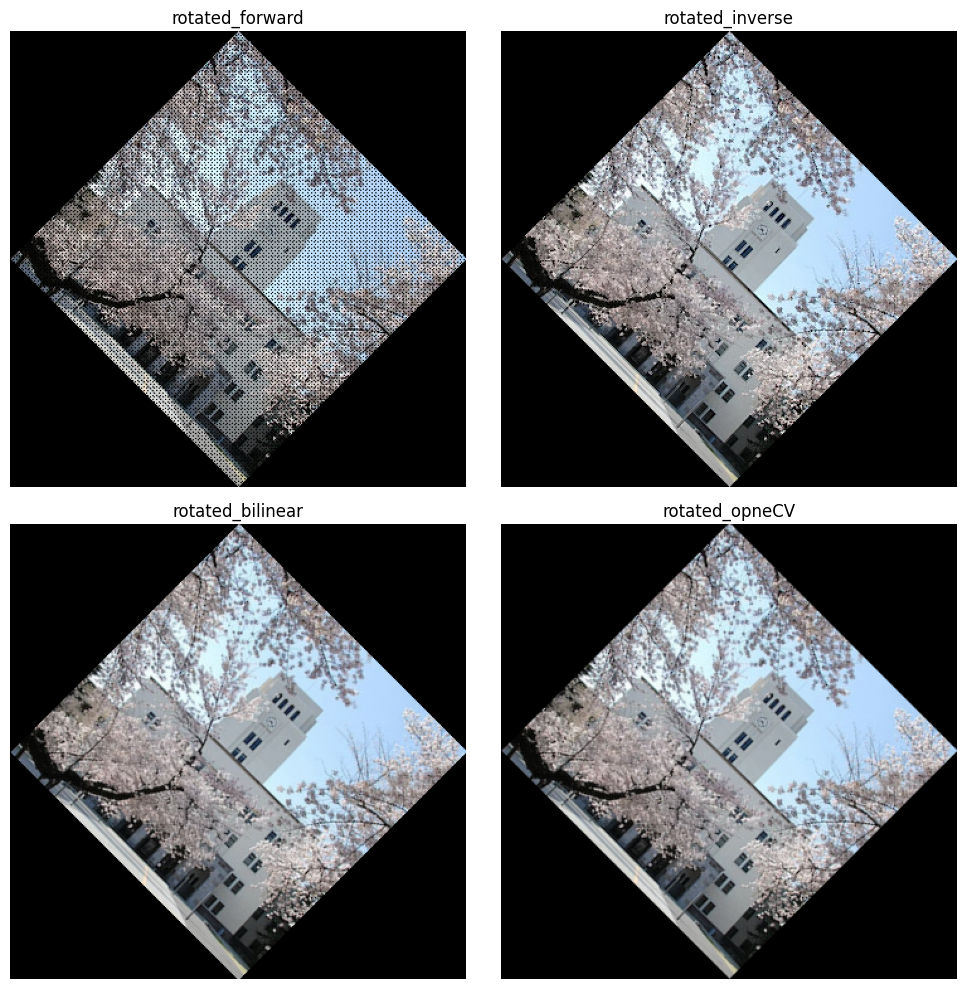

In [25]:
# 2 x 2 図を作成
fig, axes = plt.subplots(2, 2, figsize=(10, 10))  # figsize（横, 縦）は適宜調整可

#回転角
degree = 45

# 左上：順マッピング・最近傍補間
ax = axes[0, 0]
ax.imshow( rotate_forword(img, matrix_R(degree)) )
ax.set_title('rotated_forward')
ax.axis('off')

# 右上：逆マッピング・最近傍補間
ax = axes[0, 1]
ax.imshow( rotate_inverse(img, matrix_R(degree)) )
ax.set_title('rotated_inverse')
ax.axis('off')

# 左下：逆マッピング・バイリニア補間
ax = axes[1, 0]
ax.imshow( rotate_bilinear(img, matrix_R(degree)) )
ax.set_title('rotated_bilinear')
ax.axis('off')

# 右下：OpenCV ライブラリを使った回転
ax = axes[1, 1]
ax.imshow( rotate_openCV(img,degree) )
ax.set_title('rotated_opneCV')
ax.axis('off')

plt.tight_layout()
plt.show()


### 視覚的考察

順方向のマッピングでは入力画像の2つ以上のピクセルが出力画像の1つのピクセルに入ることがあるため、結果的に出力画像のすべてのピクセルが埋まらない。そのため、見た目からも明らかに画像に穴が存在する。画素数が少ないため視覚的には逆マッピングの二つの手法とライブラリによる回転の差はわからなかった。

### 実行時間の比較



In [26]:
print("順マッピング・最近傍補間の実行時間")
time_forward = timeit.timeit(lambda: rotate_forword(img, matrix_R(degree)), number=5)
print(f"{time_forward:.6f} 秒（5回の平均）")

print("逆マッピング・最近傍補間の実行時間")
time_inverse = timeit.timeit(lambda: rotate_inverse(img, matrix_R(degree)), number=5)
print(f"{time_inverse:.6f} 秒（5回の平均）")

print("逆マッピング・バイリニア補間の実行時間")
time_bilinear = timeit.timeit(lambda: rotate_bilinear(img, matrix_R(degree)), number=5)
print(f"{time_bilinear:.6f} 秒（5回の平均）")

print("openCV ライブラリの実行時間")
time_openCV = timeit.timeit(lambda: rotate_openCV(img, degree), number=5)
print(f"{time_openCV:.6f} 秒（5回の平均）")


順マッピング・最近傍補間の実行時間
2.181233 秒（5回の平均）
逆マッピング・最近傍補間の実行時間
4.137739 秒（5回の平均）
逆マッピング・バイリニア補間の実行時間
5.286837 秒（5回の平均）
openCV ライブラリの実行時間
0.002692 秒（5回の平均）


### 実行時間の考察

1.ライブラリとの比較

手実装による回転処理の実行時間はライブラリを使用した場合に比べいずれも1000倍近く時間がかかった。これはOpenCVがC++で最適化されたライブラリであり、並列処理などが活用されているためである。一方、Numpy,mathによる実装はPythonベースで逐次的に処理されるため、ループ処理が多く処理時間が大幅に増加した。

2.補間方法による違い

最近傍補間でも順マッピングと逆マッピングで処理時間が大きく異なるのは、順マッピングでは入力画像の各ピクセルについて処理するのにた対し、逆マッピングでは回転後のサイズが大きくなった画像のすべてのピクセルについて処理しているためである。バイリニア補間では処理が多いため、最も実行時間が長くなっている。

### 回転精度の比較
手実装による45°回転の画像とライブラリを用いた画像を比較することで回転処理の正確性を計測する。各ピクセルの値について、手実装の場合とライブラリを用いた場合で差をとり、二乗平均を算出することで精度を評価する（MSE）。値が小さいほど精度が高い。

In [27]:
def compute_mse(img1, img2):
    return np.mean((img1.astype("float32") - img2.astype("float32")) ** 2)

#回転後の画像を取得
rotated_forword = rotate_forword(img, matrix_R(degree))
rotated_inverse = rotate_inverse(img, matrix_R(degree))
rotated_bilinear = rotate_bilinear(img, matrix_R(degree))
rotated_openCV = rotate_openCV(img, degree)

#mseを計算
accuracy_forword = compute_mse(rotated_openCV,rotated_forword)
accuracy_inverse = compute_mse(rotated_openCV, rotated_inverse)
accuracy_bilinear = compute_mse(rotated_openCV, rotated_bilinear)

#mseを出力
print("順マッピング・最近傍補間：",accuracy_forword)
print("逆マッピング・最近傍補間：",accuracy_inverse)
print("逆マッピング・バイリニア補間：",accuracy_bilinear)

順マッピング・最近傍補間： 2484.1553
逆マッピング・最近傍補間： 125.607155
逆マッピング・バイリニア補間： 114.22278


### 回転の正確性の比較

１．順マッピング・最近傍補間について

順マッピングと最近傍補間を組み合わせた場合に誤差が最も大きくなった。これは視覚的にもわかるように回転後の出力画像において一部のピクセルがどの入力ピクセルからもマッピングされず、穴が生じたり、ピクセル単位補間処理により画像が荒くなるためである。

２．逆マッピング・最近傍補間について

逆マッピングにより大幅に精度が改善されたのは出力画像のすべてのピクセルに対して入力画像の座標を逆算するため、穴が生じることがなくなるためである。最近傍補間により単純に画素値を取得しているが、構造的にすべてのピクセルが適切な値を持つため、誤差が大幅に小さくなっている。

３．バイリニア補間について

バイリニア補間では、入力画像の周囲４ピクセルを使って重み付けした平均の色を用いているため、最も精度の高い回転処理となった。しかしながら最近傍補間との大きな差は見られなかった。回転を繰り返し適用したり、画素数の大きな画像を対象とすることで差が大きくなると考えられる。

４．まとめ

順方向のマッピングは非常に精度が悪いが、逆マッピングにすることで精度が大幅に向上する。
視覚的には逆マッピングの最近傍補間とバイリニア補間の差はわからなかったが、数値化することで精度に差があることが認められた。

### 実行時間と精度の関係

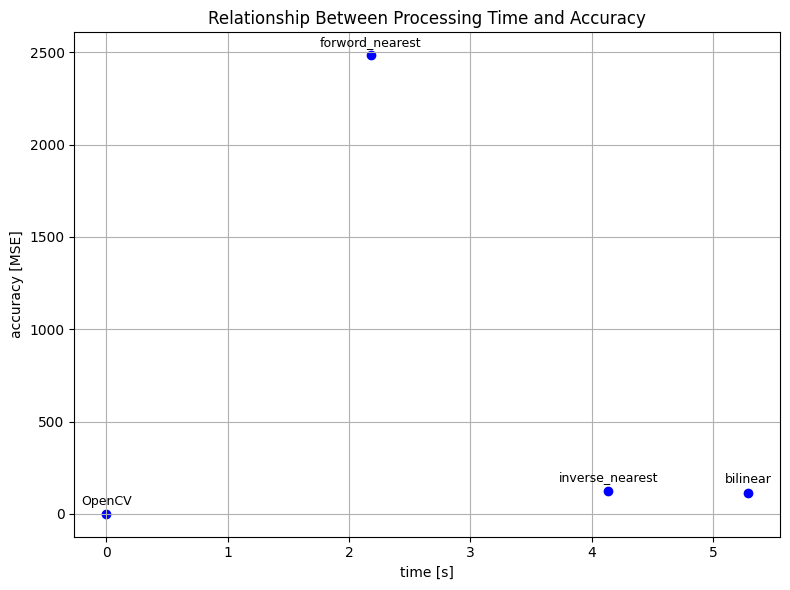

In [28]:
# データ定義
time = (time_forward, time_inverse, time_bilinear, time_openCV)  # 処理時間 [ms]
accuracy = (accuracy_forword, accuracy_inverse, accuracy_bilinear, 0)  # 精度
labels = ["forword_nearest", "inverse_nearest", "bilinear", "OpenCV"]

# 図のサイズ設定
plt.figure(figsize=(8, 6))

# 散布図の描画
plt.scatter(time, accuracy, color='blue')

# 各点にラベルを表示
for i, label in enumerate(labels):
    plt.text(time[i], accuracy[i] + 50, label, ha='center', fontsize=9)

# 軸ラベルとタイトル
plt.xlabel("time [s]")
plt.ylabel("accuracy [MSE]")
plt.title("Relationship Between Processing Time and Accuracy")

# グリッドを表示
plt.grid(True)

# 図のレイアウトを調整して表示
plt.tight_layout()
plt.show()

### まとめと今後の課題

本レポートでは、画像回転処理のための線形代数を理解したうえで、NumPyを用いて回転アルゴリズムを自ら実装し、OpenCVなどの既存ライブラリとの性能比較を行った。実装を通じて、回転行列と逆マッピングの重要性、補間処理の違いが画質に与える影響などを実践的に学ぶことができた。

今後の課題として、３つの点が考えられる。

１．より精度が高くなるような補間方法を実装し、さらなる画質改善を行いたい。

２．回転や補間などの計算負荷の高い処理部分をC++で実装し、Pythonからctypesやpybind11を用いて呼び出すことで、処理速度を向上させたい。

３．現在の評価では、1枚の低解像度画像を単一角度で回転させ、アルゴリズムの比較を行っているが、今後はより定量的、多角的に性能を評価したい。また、微小角度の回転を繰り返すことによる画像の劣化について調べることで動画処理や逐次的な回転が必要な実践的な場合を考慮した評価を行いたい。